In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1 import make_axes_locatable

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
import seaborn as sns
import warnings
from matplotlib.patches import Patch
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from matplotlib.collections import PolyCollection
warnings.filterwarnings('ignore')

In [2]:
def off_target_plot_final(
		date, 
		test_name, 
		baseline, 
		treatments, 
		day_numbers, 
		merge_method_replicate, 
		manual_bin = None,
		manual_bin_label = None,
		per_time_unit=True):
	
	# merge 4 replicates
	# copied from handling negative control sgRNAs
	df_test = None
	for treatment in treatments:
		df_test_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_test_rep = pd.read_csv(df_test_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_test_rep = df_test_rep[df_test_rep["Gene"].isin(["MYC_GFP", "MYC_SNP1", "MYC_SNP2", "MYC_SNP3", "MYC_STOP"])]
		df_test_rep = df_test_rep.drop('Gene', axis=1)
		df_test_rep = df_test_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_test is None:
			df_test = df_test_rep
		else:
			# Merge on 'sgrna'
			df_test = pd.merge(df_test, df_test_rep, on="sgrna", how="inner")
	print(len(df_test))

	treatment_lfc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df_test[col] = df_test[col] / (day + 0) # per time unit. 

	if merge_method_replicate == "mean":
		df_test["per time unit LFC"] = df_test[treatment_lfc_columns].mean(axis=1)
	df_test = df_test[["sgrna", "per time unit LFC"]]

	mismatch_number = 1
	df_off_path = f"/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch{mismatch_number}.processed.tsv"
	df_off = pd.read_csv(df_off_path, sep="\t")
	alignment_col = f"Alignments_NM_less_than_{mismatch_number}"
	df_lib_path = "/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.myc2_indel.organized.txt"
	df_lib = pd.read_csv(df_lib_path, sep="\t", usecols=["id", "seq_name", "indel_consequences", "indel_repeats"])

	df = pd.merge(df_lib, df_test, left_on='id', right_on='sgrna')
	df = pd.merge(df, df_off, left_on='id', right_on='id', how='left')

	df['Alignments_NM0'] = df['Alignments_NM0'].fillna(0).astype(int)
	df['Alignments_NM1'] = df['Alignments_NM1'].fillna(0).astype(int)
	df[alignment_col] = df[alignment_col].fillna(0).astype(int)	# actually "no more than" instead of "less than" 
	df[df[alignment_col] == 0].groupby('indel_consequences').size().sort_values(ascending=False)
	# overlapping with GFP
	df.loc[(df[alignment_col] == 0) & (df['indel_consequences'] == 'coding'), alignment_col] = 1
	df.loc[(df[alignment_col] == 0) & (df['indel_consequences'] == '3_prime_UTR'), alignment_col] = 1


	# df_nc = df[df['seq_name'].isin(["AAVS1", "NT", "Random"])]
	# if use: add neg ctrl mismatch
	df = df[(df['seq_name'].isin(["MYC_GFP", "MYC_SNP1", "MYC_SNP2", "MYC_SNP3", "MYC_STOP"])) & (df['indel_consequences'] != "GFP")]

	# plot prep
	df['log10_alignments'] = np.log10(df[alignment_col])
	finite_log10_alignments = df['log10_alignments'].replace([np.inf, -np.inf], np.nan).dropna()
	offtarget_x_min = finite_log10_alignments.min()
	offtarget_x_max = finite_log10_alignments.max()
	if offtarget_x_min == offtarget_x_max:
		offtarget_x_max = offtarget_x_min + 1
	if manual_bin is not None:
		offtarget_bin_edges = manual_bin
		offtarget_bin_labels = manual_bin_label
	else:
		n_offtarget_bins = 15
		offtarget_bin_edges = np.linspace(offtarget_x_min, offtarget_x_max, n_offtarget_bins + 1)
	print(df[df['log10_alignments'] == 0].groupby('indel_repeats').size())	# perfect match
	# Why are indel_repeats=True having perfect match?
	perfect_match_repeats = df[(df['log10_alignments'] == 0) & (df['indel_repeats'] == True)]['id'].tolist()
	print(perfect_match_repeats[:5])
	# they are simple repeats

	# figures for the text
	n1 = len(df[df['indel_repeats'] == False])
	n2 = len(df[(df['indel_repeats'] == False) & (df['log10_alignments'] == 0)])
	print(f"non-repeat-targeting sgRNAs: {n1}")
	print(f"non-repeat-targeting sgRNAs with no off-targets: {n2}")
	print(n2/n1)

	# scatter plot

	fig, ax = plt.subplots(figsize=(4.5, 2.7))
	divider = make_axes_locatable(ax)
	sns.scatterplot(data=df, x='log10_alignments', y='per time unit LFC', hue='indel_repeats', s=1.5, alpha=1.0, palette={False: '#FF0066', True: '#40007F'}, ax=ax)
	plt.xlabel('Log10(alignment in the genome)', fontsize=13)
	plt.ylabel('sgRNA phenotype score', fontsize=13)
	plt.xticks(fontsize=12)
	plt.yticks(fontsize=12)
	plt.xlim(offtarget_x_min, offtarget_x_max)
	plt.grid(False)
	plt.gca().legend_.remove()
	plt.tight_layout()
	ax_box = ax.get_position()
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	# plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/screening/offtargets_sgrna_lfc.pdf", 
	# 			bbox_inches="tight",
	# 			dpi=300,              
	# 			transparent=True,
	# 			format='pdf')
	plt.show()

	# scatterplot - split:
	fig, axes = plt.subplots(
		nrows=1,
		ncols=2,
		figsize=(9.0, 2.7),
		sharex=True,
		sharey=True
	)

	palette = {
		False: '#FF0066',
		True: '#40007F'
	}

	for ax, indel_repeat in zip(axes, [False, True]):
		subset = df[df['indel_repeats'] == indel_repeat]

		sns.scatterplot(
			data=subset,
			x='log10_alignments',
			y='per time unit LFC',
			s=1.5,
			alpha=1.0,
			color=palette[indel_repeat],
			ax=ax,
			legend=False
		)

		ax.set_title(f'indel_repeats = {indel_repeat}', fontsize=13)
		ax.set_xlabel('Log10(alignment in the genome)', fontsize=13)
		ax.set_xlim(offtarget_x_min, offtarget_x_max)
		ax.tick_params(axis='both', labelsize=12)
		ax.grid(False)
		ax.spines['top'].set_visible(False)
		ax.spines['right'].set_visible(False)

	axes[0].set_ylabel('sgRNA phenotype score', fontsize=13)
	axes[1].set_ylabel('')

	plt.tight_layout()

	# sgRNA % plot
	plt.figure(figsize=(4.5, 2.5))

	df_pct = df.copy()

	df_pct["offtarget_bin"] = pd.cut(
		df_pct["log10_alignments"],
		bins=offtarget_bin_edges,
		labels=offtarget_bin_labels,
		include_lowest=True,
		right=True
	)

	df_pct = df_pct.dropna(subset=["offtarget_bin"])

	count_df = (
		df_pct
		.groupby(["indel_repeats", "offtarget_bin"], observed=False)
		.size()
		.reset_index(name="n")
	)

	count_df["percent"] = (
		count_df["n"] /
		count_df.groupby("indel_repeats")["n"].transform("sum") *
		100
	)

	ax = sns.barplot(
		data=count_df,
		x="offtarget_bin",
		y="percent",
		hue="indel_repeats",
		order=offtarget_bin_labels,
		hue_order=[False, True],
		palette={False: "#FF0066", True: "#40007F"}
	)

	plt.xlabel('Log10(alignment in the genome)', fontsize=13)
	plt.ylabel('sgRNA % (of each group)', fontsize=13)
	plt.xticks(offtarget_bin_labels, fontsize=12, rotation=45, ha="right")
	plt.yticks(fontsize=12)
	plt.grid(False)
	sns.move_legend(ax, "upper right", title="Indel repeats", fontsize=12, title_fontsize=12, frameon=False)
	plt.tight_layout()
	ax.set_position(ax_box)
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/offtargets_percentage.mismatch{mismatch_number}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# sgRNA phenotype score distribution by off-target bin
	if manual_bin is None:
		offtarget_bin_labels = [
			f"{offtarget_bin_edges[i]:.1f}-{offtarget_bin_edges[i + 1]:.1f}"
			for i in range(len(offtarget_bin_edges) - 1)
		]
	print(offtarget_bin_labels)
	df_violin = df.copy()
	df_violin['offtarget_bin'] = pd.cut(
		df_violin['log10_alignments'],
		bins=offtarget_bin_edges,
		labels=offtarget_bin_labels,
		include_lowest=True,
		right=True

	)
	df_violin = df_violin.dropna(subset=['offtarget_bin', 'per time unit LFC'])

	fig, ax = plt.subplots(figsize=(4.5, 2.7))
	sns.violinplot(
		data=df_violin,
		x='offtarget_bin',
		y='per time unit LFC',
		hue='indel_repeats',
		hue_order=[False, True],
		order=offtarget_bin_labels,
		split=True,
		inner=None,
		cut=0,
		scale='width',
		linewidth=0.6,
		palette={False: '#FF0066', True: '#40007F'},
		ax=ax
	)

	gap = 0.035  # increase to widen the space between split halves

	for poly in ax.findobj(PolyCollection):
		verts = poly.get_paths()[0].vertices

		# The violin is centered on the nearest integer x position
		center = np.round(np.median(verts[:, 0]))

		# Left half: shift left. Right half: shift right.
		if np.nanmean(verts[:, 0]) < center:
			verts[:, 0] -= gap
		else:
			verts[:, 0] += gap

	# Median per bin for each group
	median_df = (
		df_violin
		.groupby(["offtarget_bin", "indel_repeats"], observed=True)["per time unit LFC"]
		.median()
		.reset_index()
	)

	# Convert categorical bin labels to numeric x positions
	bin_to_x = {label: i for i, label in enumerate(offtarget_bin_labels)}

	median_df["x"] = (
		median_df["offtarget_bin"]
		.astype(str)
		.map(bin_to_x)
		.astype(float)
	)

	median_df["x_offset"] = median_df["x"] + median_df["indel_repeats"].map({
		False: -0.12 - gap,
		True: 0.12 + gap
	}).astype(float)

	for group, color in [(False, "#F49EC0FF"), (True, "#CA98FC")]:
		sub = median_df[median_df["indel_repeats"] == group]

		ax.scatter(
			sub["x_offset"],
			sub["per time unit LFC"],
			color=color,
			s=14,
			edgecolor="black",
			linewidth=0.3,
			zorder=5
		)
	ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8, zorder=0)
	ax.set_xlabel('Log10(alignment in the genome)', fontsize=13)
	ax.set_ylabel('sgRNA phenotype', fontsize=13)
	if manual_bin is None:
		tick_positions = np.arange(0, len(offtarget_bin_labels), 5)
		ax.set_xticks(tick_positions)
		ax.set_xticklabels([f"{offtarget_bin_edges[i]:.1f}" for i in tick_positions], fontsize=12)
	else:
		ax.set_xticks(np.arange(len(offtarget_bin_labels)))
		ax.set_xticklabels(offtarget_bin_labels, fontsize=12, rotation=45, ha="right")
	ax.tick_params(axis='y', labelsize=12)
	ax.set_xlim(-0.5, len(offtarget_bin_labels) - 0.5)
	ax.grid(False)
	ax.get_legend().remove()
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/offtargets_lfc_violin_by_bin.mismatch{mismatch_number}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# Mann–Whitney U test between two bins for indel_repeats=False
	x_bin = 0
	y_bin = 3

	bin_x = offtarget_bin_labels[x_bin]
	bin_y = offtarget_bin_labels[y_bin]
	print(bin_x, bin_y)

	sub = df_violin[df_violin["indel_repeats"] == False].copy()

	vals_x = sub.loc[sub["offtarget_bin"].astype(str) == bin_x, "per time unit LFC"].dropna()

	vals_y = sub.loc[sub["offtarget_bin"].astype(str) == bin_y, "per time unit LFC"].dropna()

	stat, pval = mannwhitneyu(vals_x, vals_y, alternative="greater")	# H1: x is larger than y

	print(f"indel_repeats=False")
	print(f"Bin {x_bin}: {bin_x}, n={len(vals_x)}, median={vals_x.median():.4g}")
	print(f"Bin {y_bin}: {bin_y}, n={len(vals_y)}, median={vals_y.median():.4g}")
	print(f"Mann–Whitney U statistic = {stat:.4g}")
	print(f"p-value = {pval:.4g}")

22058
indel_repeats
False    10834
True       382
dtype: int64
['MYC_GFP:1891+', 'MYC_GFP:1891-', 'MYC_GFP:1892+', 'MYC_GFP:1892-', 'MYC_GFP:1895+']
non-repeat-targeting sgRNAs: 18878
non-repeat-targeting sgRNAs with no off-targets: 10834
0.5738955397817566


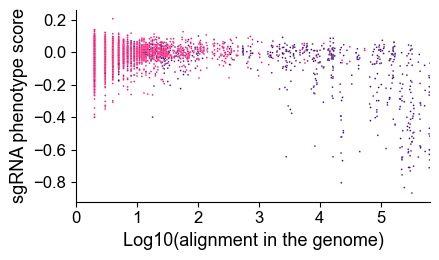

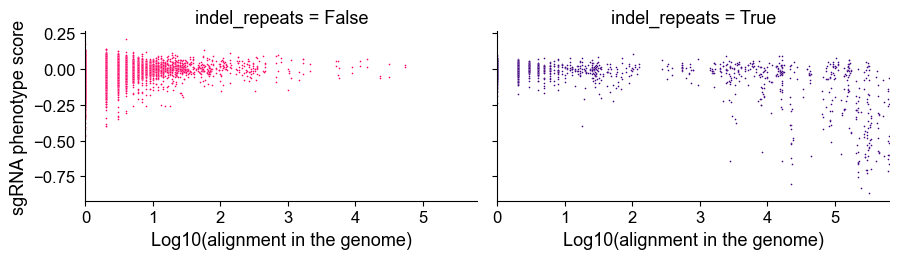

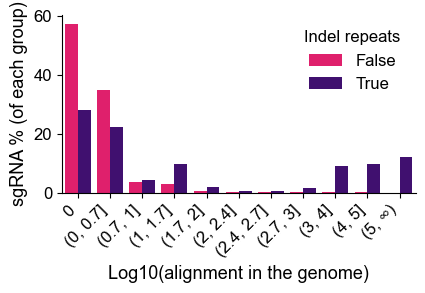

['0', '(0, 0.7]', '(0.7, 1]', '(1, 1.7]', '(1.7, 2]', '(2, 2.4]', '(2.4, 2.7]', '(2.7, 3]', '(3, 4]', '(4, 5]', '(5, ∞)']


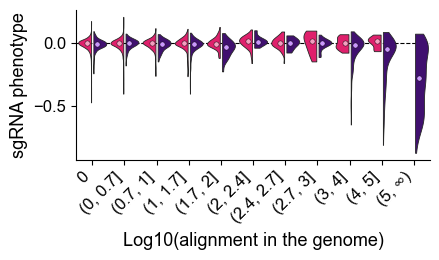

0 (1, 1.7]
indel_repeats=False
Bin 0: 0, n=10834, median=-0.003591
Bin 3: (1, 1.7], n=538, median=8.017e-05
Mann–Whitney U statistic = 2.662e+06
p-value = 0.9996


In [4]:
date = "20250416"
test_name = "test-1-standard/test"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
manual_bin = [-1, 0, 0.7, 1, 1.7, 2, 2.4, 2.7, 3, 4, 5, np.inf]
manual_bin_label = [
    "0",
    "(0, 0.7]",
    "(0.7, 1]",
    "(1, 1.7]",
    "(1.7, 2]",
    "(2, 2.4]",
	"(2.4, 2.7]",
	"(2.7, 3]",
	"(3, 4]",
    "(4, 5]",
	"(5, ∞)"
]
off_target_plot_final(
	date, 
	test_name, 
	baseline, 
	treatments, 
	day_numbers, 
	merge_method_replicate, 
	manual_bin,
	manual_bin_label,
	per_time_unit=True)